# Ejercicios semana 2 – módulo 1

## Conceptos Clave

**¿Qué es un Histograma?:** 

Es un gráfico que agrupa datos numéricos en "bins" (recipientes o rangos). Nos permite ver la forma de la distribución: si los datos están centrados, si hay muchos valores bajos o si hay una tendencia hacia el puntaje máximo.

**La variable `points`**

En este dataset, los puntos suelen ir de 80 a 100. Un histograma nos dirá, por ejemplo, si la mayoría de los vinos son "buenos" (88-90 puntos) o si los vinos "excelentes" (95+) son muy raros.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Configurar el estilo oscuro de las gráficas
plt.style.use('dark_background')
sns.set_theme(style="darkgrid")

In [3]:
# Configuración adicional para un tema más oscuro
plt.rcParams['figure.facecolor'] = '#1a1a1a'
plt.rcParams['axes.facecolor'] = '#2b2b2b'
plt.rcParams['axes.edgecolor'] = '#444444'
plt.rcParams['text.color'] = '#ffffff'
plt.rcParams['axes.labelcolor'] = '#ffffff'
plt.rcParams['xtick.color'] = '#ffffff'
plt.rcParams['ytick.color'] = '#ffffff'

In [29]:
df = pd.read_csv('data/winemag-data-130k-v2.csv')
df.head(5)

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


## Histograma

In [9]:
%matplotlib inline

In [30]:
m = df['points'].mode()
m

0    88
Name: points, dtype: int64

#### Observaciones:

1. El histograma muestra una distribución unimodal pues solo hay un solo pico en la distribución de los puntos.
2. La distribución esta centrada en el valor de 88 puntos, valor que indica la moda de la distribución.
3. El puntaje mínimo es de 80 puntos.
4. El puntaje máximo es de 100 puntos, con una frecuencia muy baja en ese extremo lo que puede indicar valores atípicos.
5. Aunque la distribución sigue una tendencia unimodal (una sola montaña), presenta una anomalía cerca de los 90 puntos que rompe la simetría, lo cual es característico de sesgos en la evaluación humana

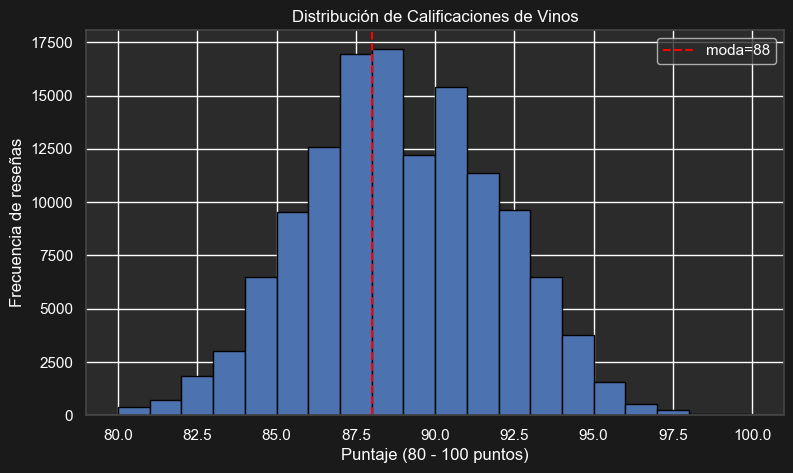

In [36]:
plt.figure(figsize=(9, 5))

df['points'].hist(bins=20, edgecolor='black')

plt.title('Distribución de Calificaciones de Vinos')
plt.xlabel('Puntaje (80 - 100 puntos)')
plt.ylabel('Frecuencia de reseñas')
plt.axvline(x=m.iloc[0], color='red', linestyle='--', label=f'moda={m.iloc[0]}')
plt.legend()
plt.show()

In [43]:
print('Puntaje mínimo:', df['points'].min())
print('Puntaje máximo:', df['points'].max())

Puntaje mínimo: 80
Puntaje máximo: 100


## Gráfico de distribución de precios

Se puede observar en el diagrama que hay valores atípicos, en este caso los precios de los vinos van desde los 4 USD hasta los 3300 USD, indicando una gran variabilidad en los precios de los vinos. 

**Conclusiones:**

1. La mayoría de los vinos tienen precios "bajos" o son de un precio promedio.
2. Hay unos datos atípicos los cuales son los precios que superan los 200 USD.

Como los outliers representan menos de 5% del dataset, se puede considerar eliminar estos datos para obtener una mejor visualización de la distribución de precios.

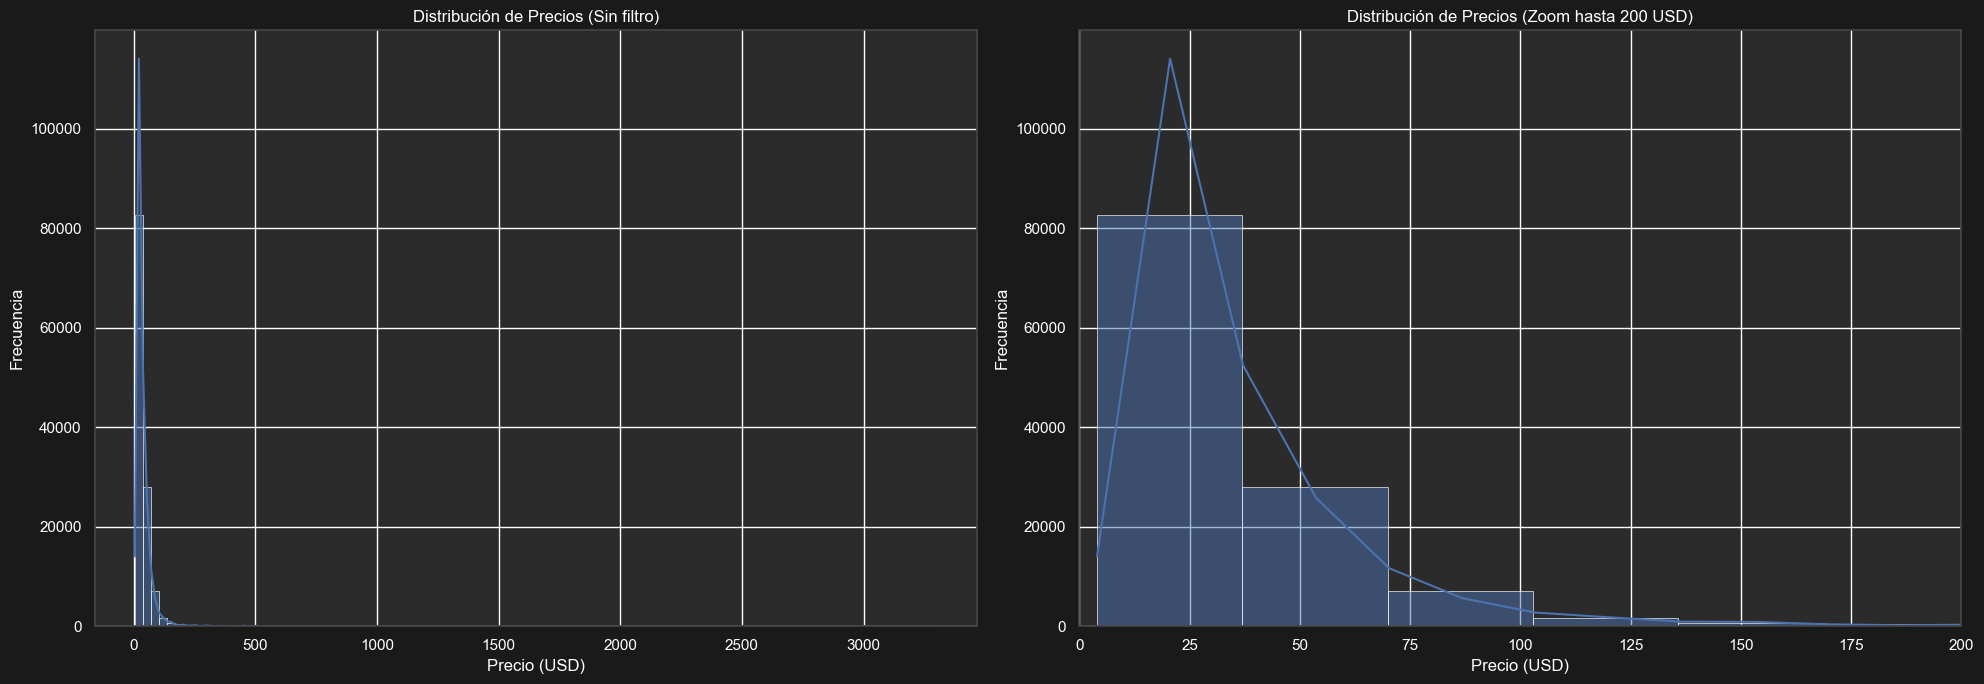

In [74]:
# Filtrar valores nulos en price para evitar errores
prices = df['price'].dropna()

f, ax = plt.subplots(1, 2, figsize=(20, 7))

# Gráfica 1: Sin límite (se observan los outliers)
sns.histplot(prices, bins=100, kde=True, ax=ax[0])
ax[0].set_title('Distribución de Precios (Sin filtro)')
ax[0].set_xlabel('Precio (USD)')
ax[0].set_ylabel('Frecuencia')

# Gráfica 2: Con límite de 200 USD para ver la concentración
sns.histplot(prices, bins=100, kde=True, ax=ax[1])
ax[1].set_xlim(0, 200)
ax[1].set_title('Distribución de Precios (Zoom hasta 200 USD)')
ax[1].set_xlabel('Precio (USD)')
ax[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [58]:
print(f'Precio mínimo: {prices.min()} USD')
print(f'Precio máximo: {prices.max()} USD')

Precio mínimo: 4.0 USD
Precio máximo: 3300.0 USD


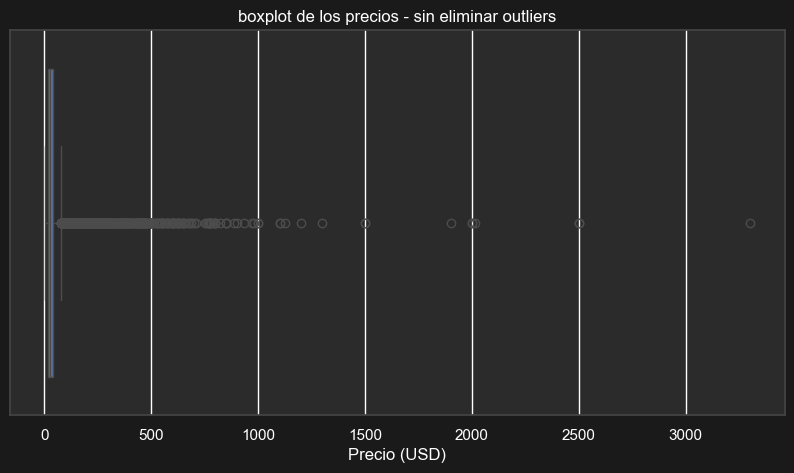

In [63]:
plt.figure(figsize=(10, 5))

# Boxplot con todos los datos de precios
sns.boxplot(x=prices)
plt.title('boxplot de los precios - sin eliminar outliers')
plt.xlabel('Precio (USD)')

plt.show()


In [ ]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

# 2. Calculamos el IQR
IQR = Q3 - Q1

# 3. Calculamos el límite superior (el bigote derecho)
limite_superior = Q3 + 1.5 * IQR

In [77]:
# Filtrar los datos que superan el límite
outliers = df[df['price'] > limite_superior]

# Contar el número de filas
num_outliers = len(outliers)
porcentaje = (num_outliers / len(df)) * 100

print(f"Número de vinos atípicos: {num_outliers}")
print(f"Representan el {porcentaje:.2f}% del dataset.")

Número de vinos atípicos: 7241
Representan el 5.57% del dataset.


In [78]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[df['price'] <= Q3 + 1.5 * IQR]

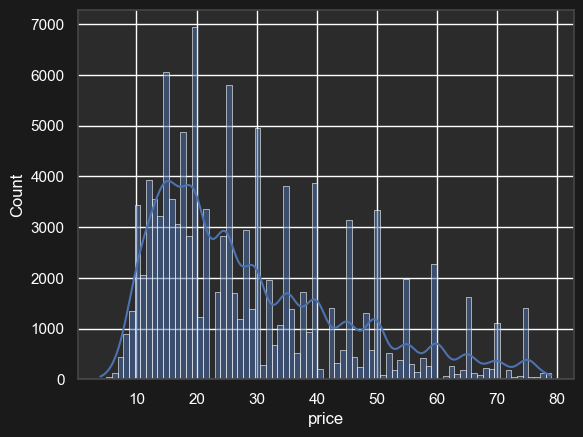

In [79]:
sns.histplot(df_clean['price'], kde=True)
plt.show()

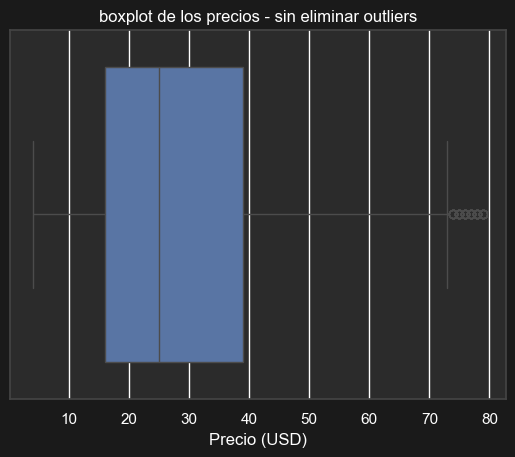

In [81]:
sns.boxplot(x=df_clean['price'])
plt.title('boxplot de los precios - sin eliminar outliers')
plt.xlabel('Precio (USD)')

plt.show()


## Países con los vinos mas caros y mas valorados

Se compara los dos datasets, el original y el dataset limpio, para observar si hay cambios en los países con los vinos más caros y mejor valorados.

Al comparar ambos datasets, se observa que no hay grandes cambios en los países de este top 20, incluso los 4 primeros países con el vino mas caro tienen el mismo orden en ambos datasets.

In [90]:
# Sin limpieza de outliers
country_stats = df.groupby('country')[['price', 'points']].mean().sort_values(by='points', ascending=False)
country_stats.head(10)

,price,points
country,,
England,51.681159,91.581081
India,13.333333,90.222222
Austria,30.762772,90.101345
Germany,42.257547,89.851732
Canada,35.712598,89.369650
Hungary,40.648276,89.191781
China,18.000000,89.000000
France,41.139120,88.845109
Luxembourg,23.333333,88.666667


/var/folders/5x/k_jbfmz552vf3px123kjh20r0000gn/T/ipykernel_13155/3829843472.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


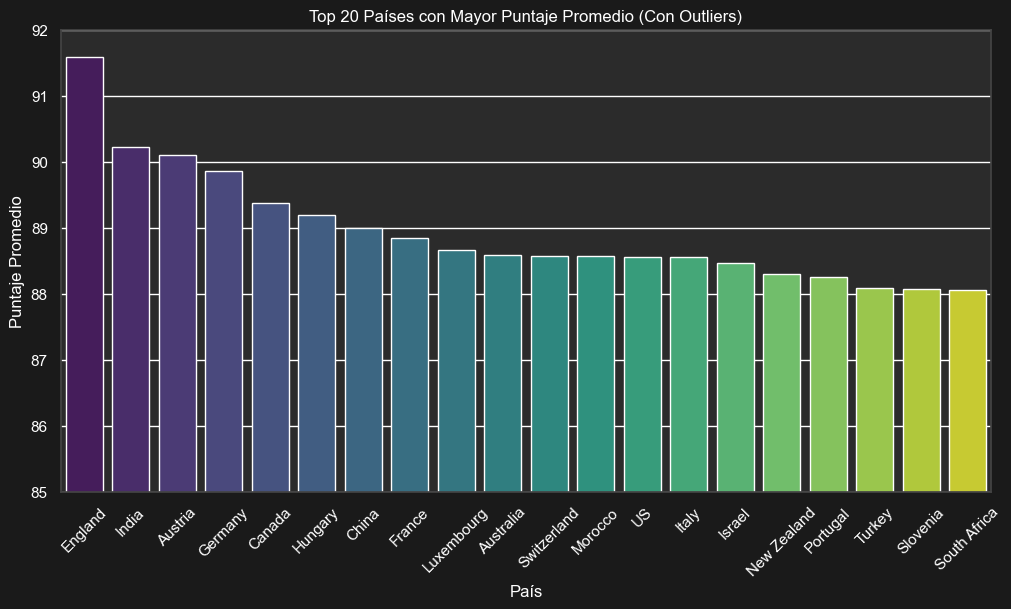

In [91]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=country_stats.index[:20], 
    y=country_stats['points'][:20], 
    palette='viridis'
)

plt.title('Top 20 Países con Mayor Puntaje Promedio (Con Outliers)')
plt.xlabel('País')
plt.ylabel('Puntaje Promedio')
plt.ylim(85, 92) # Ajuste para notar mejor las diferencias
plt.xticks(rotation=45)

plt.show()

In [92]:
# Con limpieza de outliers
country_stats = df_clean.groupby('country')[['price', 'points']].mean().sort_values(by='points', ascending=False)
country_stats.head(10)

,price,points
country,,
England,48.666667,91.396825
India,13.333333,90.222222
Austria,28.667155,90.103006
Germany,29.295840,89.561376
Canada,32.397490,89.297071
China,18.000000,89.000000
Hungary,30.029197,88.875912
Luxembourg,23.333333,88.666667
Morocco,19.500000,88.571429


/var/folders/5x/k_jbfmz552vf3px123kjh20r0000gn/T/ipykernel_13155/2003963623.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


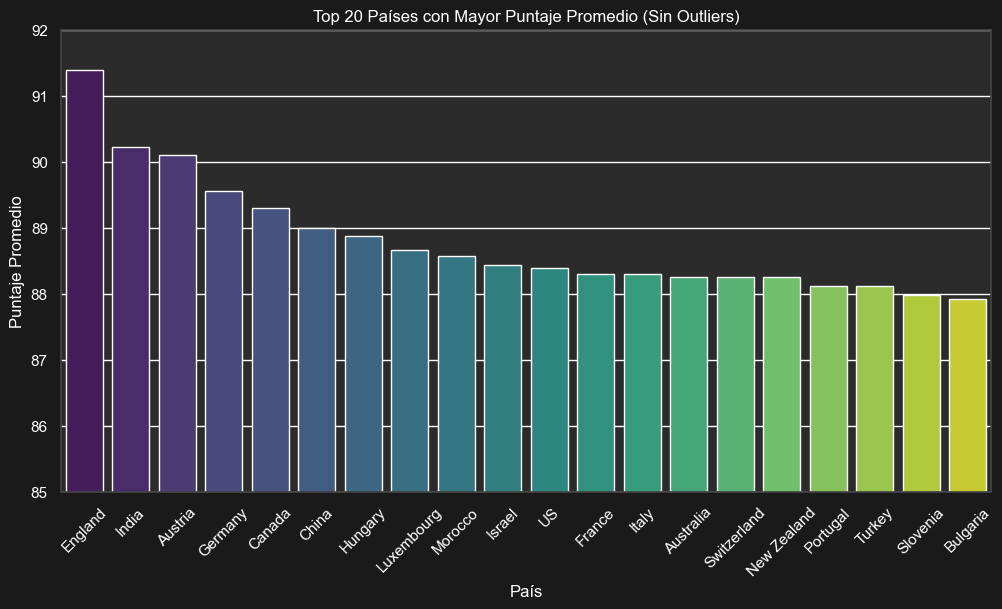

In [93]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=country_stats.index[:20], 
    y=country_stats['points'][:20], 
    palette='viridis'
)

plt.title('Top 20 Países con Mayor Puntaje Promedio (Sin Outliers)')
plt.xlabel('País')
plt.ylabel('Puntaje Promedio')
plt.ylim(85, 92) # Ajuste para notar mejor las diferencias
plt.xticks(rotation=45)

plt.show()

/var/folders/5x/k_jbfmz552vf3px123kjh20r0000gn/T/ipykernel_13155/1745956228.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


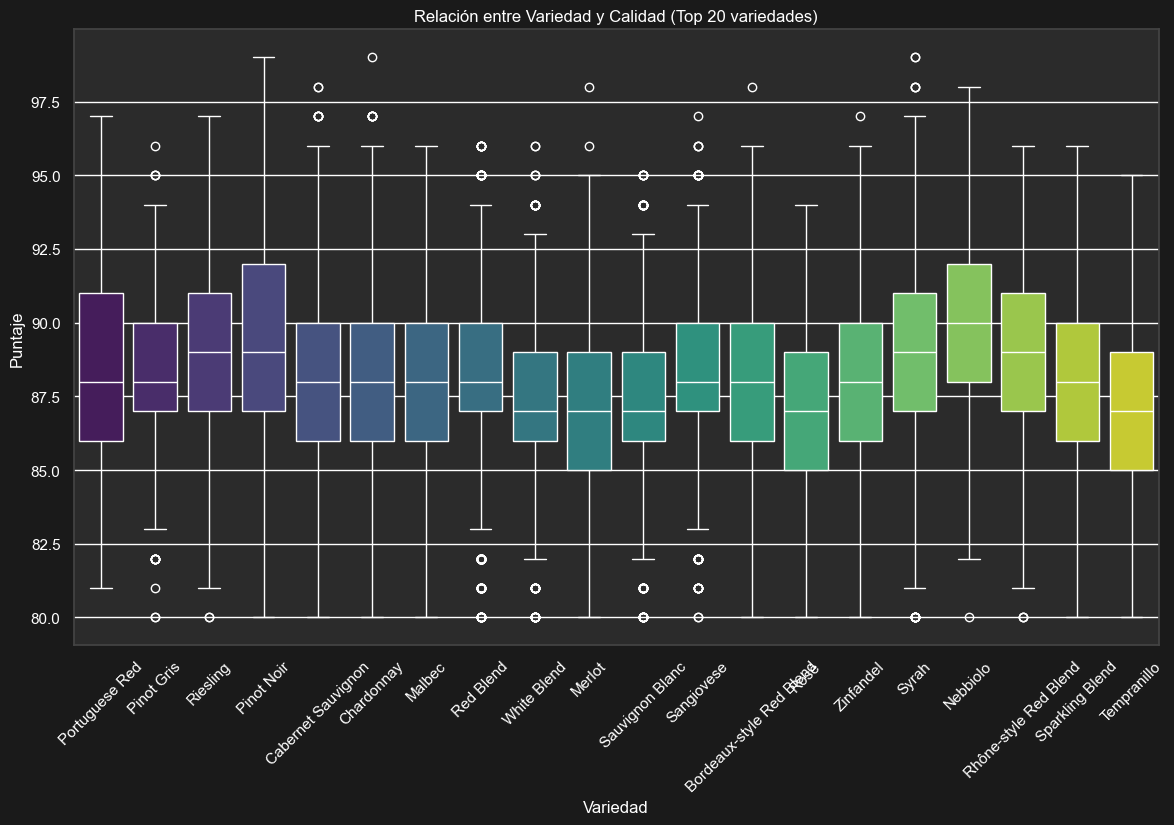

In [101]:
top_varieties = df_clean['variety'].value_counts().nlargest(20).index
df_top_varieties = df_clean[df_clean['variety'].isin(top_varieties)]

plt.figure(figsize=(14, 8))
sns.boxplot(
	x='variety', 
	y='points', 
	data=df_top_varieties, 
	palette='viridis',
	boxprops={'edgecolor': 'white'},
	whiskerprops={'color': 'white'},
	capprops={'color': 'white'},
	medianprops={'color': 'white'},
	flierprops={'markeredgecolor': 'white'}
)

plt.title('Relación entre Variedad y Calidad (Top 20 variedades)')
plt.xlabel('Variedad')
plt.ylabel('Puntaje')
plt.xticks(rotation=45)
plt.show()

## Puntaje Nacional

In [103]:
# Calcular el promedio de puntos por país
country_avg_points = df_clean.groupby('country')['points'].transform('mean')

# Crear la nueva columna 'score points' usando la función loc
df_clean.loc[:, 'score points'] = df_clean['points'] / country_avg_points
df_clean.head(5)

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery,score points
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos,0.987279
2,2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm,0.984315
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian,0.984315
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks,0.984315
5,5,Spain,Blackberry and raspberry aromas show a typical...,Ars In Vitro,87,15.0,Northern Spain,Navarra,NaN,Michael Schachner,@wineschach,Tandem 2011 Ars In Vitro Tempranillo-Merlot (N...,Tempranillo-Merlot,Tandem,0.999430


In [ ]:
# Calcular el precio promedio por país
country_avg_price = df_clean.groupby('country')['price'].transform('mean')

# Rellenar los valores nulos en 'price' con el promedio del país correspondiente
df_clean['price'] = df_clean['price'].fillna(country_avg_price)

# En caso de que exista algún país sin ningún precio registrado en el dataset,
# se puede llenar el remanente con el promedio global de precios.
df_clean['price'] = df_clean['price'].fillna(df_clean['price'].mean())

# Verificar que ya no haya valores nulos en la columna de precios
print("Valores faltantes en 'price':", df_clean['price'].isnull().sum())

Valores faltantes en 'price': 0


In [106]:
# Definir las palabras a buscar
words_to_find = ['tropical', 'fruity']

# Diccionario para almacenar los conteos
word_counts = {}

for word in words_to_find:
    # Contar cuántas descripciones contienen la palabra (sin distinguir mayúsculas)
    count = df['description'].str.contains(word, case=False).sum()
    word_counts[word] = count
    print(f"La palabra '{word}' aparece {count} veces en las descripciones.")

La palabra 'tropical' aparece 3800 veces en las descripciones.
La palabra 'fruity' aparece 9455 veces en las descripciones.


In [111]:
# Aplicando estandarizacion (Min-Max Scaling) para generar un score de 1 a 5 (floats).
# Se calculan los valores minimo y maximo de la columna de puntos ('points') del clean dataset.
# El valor estandarizado de 0 a 1 se multiplica por la diferencia del rango deseado (5 - 1)
# y se le suma el valor minimo del rango (1).

min_points = df_clean['points'].min()
max_points = df_clean['points'].max()

df_clean['score_5'] = ((df_clean['points'] - min_points) / (max_points - min_points)) * 4.0 + 1.0

df_clean[['points', 'score_5']].drop_duplicates().sort_values('points').head(40)

,points,score_5
344,80,1.000000
343,81,1.210526
338,82,1.421053
336,83,1.631579
1122,84,1.842105
51,85,2.052632
29,86,2.263158
1,87,2.473684
89,88,2.684211
254,89,2.894737
